In [6]:
# if on colab, run this call to do install
import sys

if "google.colab" in sys.modules:
    !git clone --quiet --recursive https://github.com/gmberton/vismatch.git
    %cd vismatch
    !pip install --progress-bar off --quiet -r requirements.txt
    !pip install --progress-bar off --quiet -e .

In [ ]:
from vismatch import get_matcher, available_models
from vismatch.viz import plot_matches, plot_keypoints
from pathlib import Path
import torch
import numpy as np
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
ransac_kwargs = {"ransac_reproj_thresh": 3, "ransac_conf": 0.995, "ransac_iters": 2000}  # optional ransac params
matcher = get_matcher(["superpoint-lightglue"], device=device, **ransac_kwargs)  # try an ensemble!

### Match Image Pair

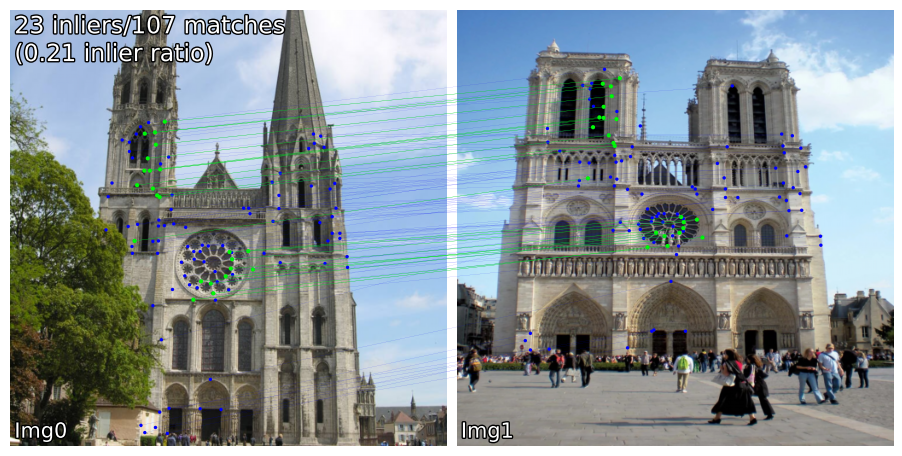

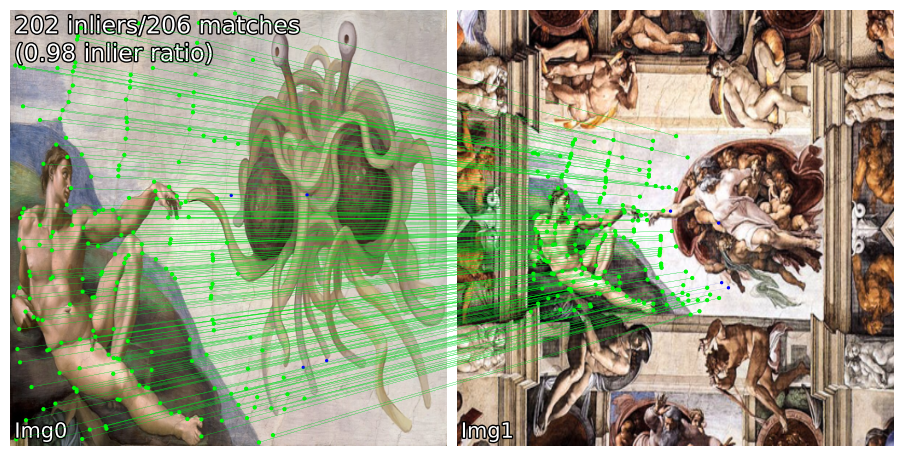

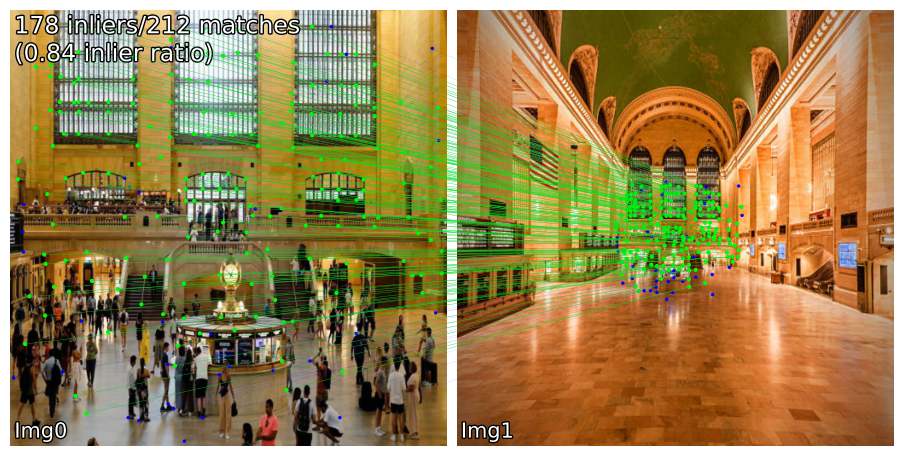

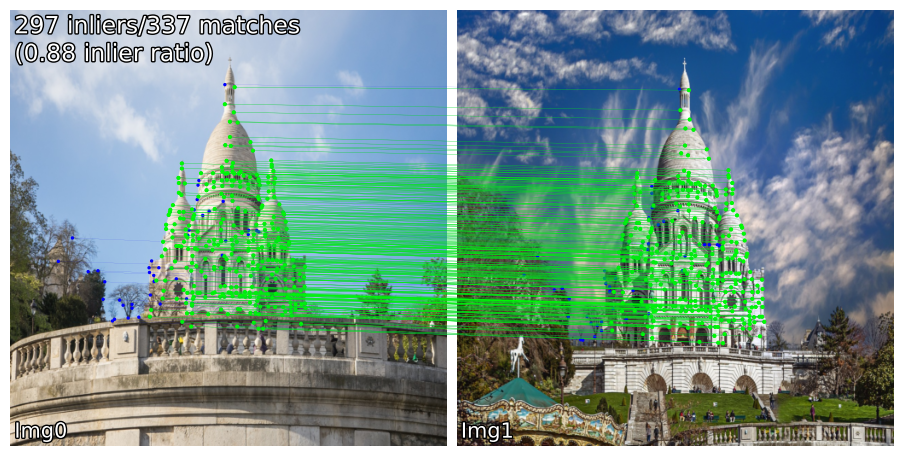

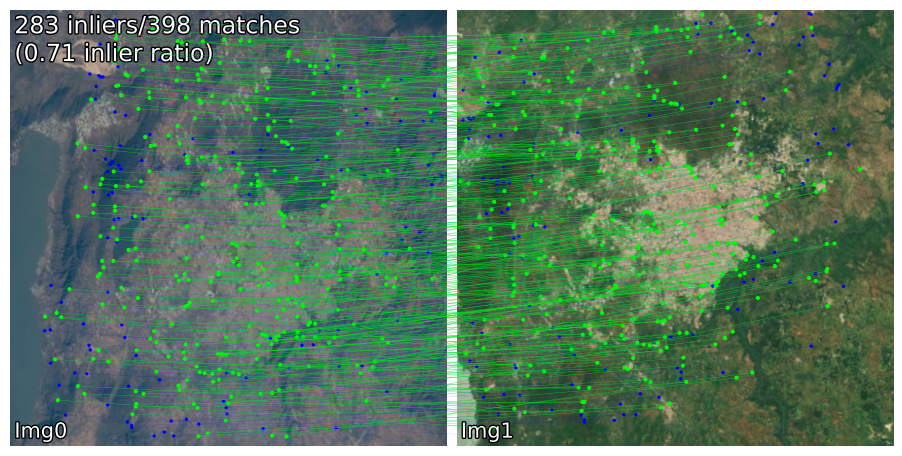

In [ ]:
asset_dir = Path("vismatch/assets/example_pairs")
pairs = list(asset_dir.iterdir())
image_size = 512
for pair in pairs:
    pair = list(pair.iterdir())
    img0 = matcher.load_image(pair[0], resize=image_size)
    img1 = matcher.load_image(pair[1], resize=image_size)

    result = matcher(img0, img1)
    num_inliers, H, mkpts0, mkpts1 = result["num_inliers"], result["H"], result["inlier_kpts0"], result["inlier_kpts1"]

    plot_matches(img0, img1, result)

### Extract Kpts and Descriptors

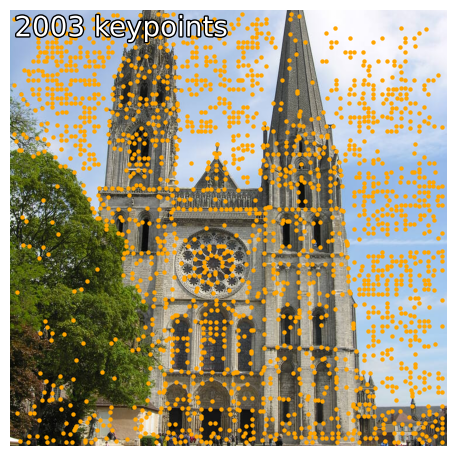

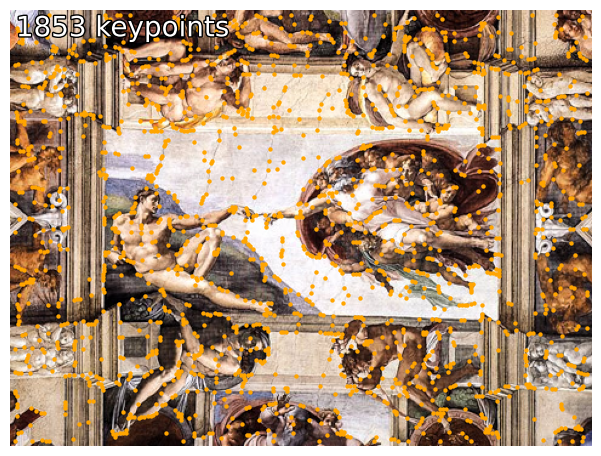

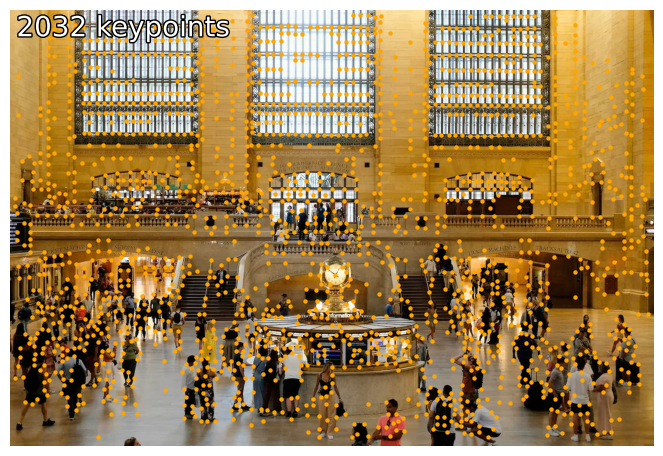

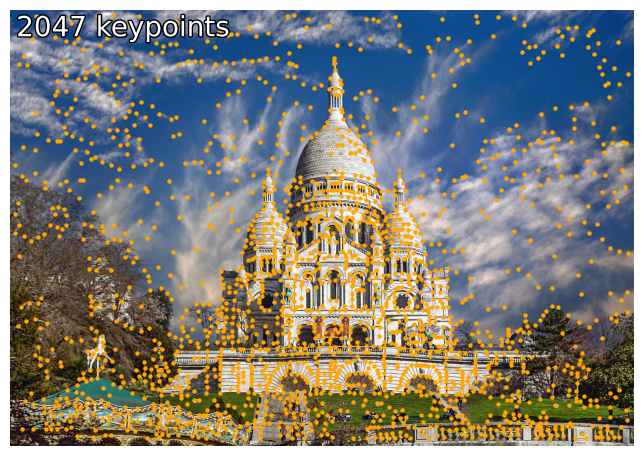

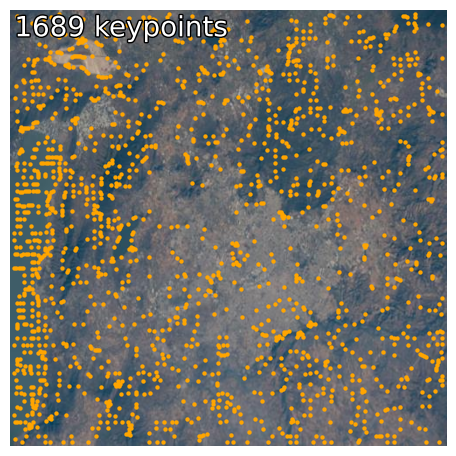

In [ ]:
asset_dir = Path("vismatch/assets/example_pairs")
pairs = list(asset_dir.iterdir())
image_size = 512
for pair in pairs:
    path = np.random.choice(list(pair.iterdir()))
    img = matcher.load_image(path)

    result = matcher.extract(img)

    plot_keypoints(img, result)

### See all matchers on the same image pair

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
%%capture

image_size = 512
img0 = matcher.image_loader(pair[0], resize=image_size)
img1 = matcher.image_loader(pair[1], resize=image_size)

figs = []
for model in available_models:
    try:
        matcher = get_matcher(model, device=device)
        result = matcher(img0, img1)
        plot_matches(img0, img1, result, show_text=False, show_matched_kpts=False, lw=0.1, ps=1)
        plt.suptitle(f"{model}: {result['num_inliers']} inliers")
        figs.append(plt.gcf())
    except Exception as e:
        print(f"Error with {model}: {e}")

In [ ]:
figs[0]  # show first figure, or iterate through figs to see all